In [1]:
# Imports and Configurations

import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# ── File paths ────────────────────────────────────────────────────────────────
EXCEL_INPUT  = "Swap and Swaption Markets.xlsx"


In [2]:
# Loading Market Data from Excel

def tenor_to_years(t: str) -> float:
    """Convert tenor string ('6m', '1wk', '2y', '18m') to decimal years."""
    t = str(t).strip()
    if re.fullmatch(r"\d+wk", t, re.I): return int(re.findall(r"\d+", t)[0]) / 52
    if re.fullmatch(r"\d+m",  t, re.I): return int(re.findall(r"\d+", t)[0]) / 12
    if re.fullmatch(r"\d+[yY]", t):     return float(re.findall(r"\d+", t)[0])
    return float(t)


def years_to_label(y: float) -> str:
    """Convert decimal years to a readable tenor label."""
    if y < 1.0 / 12:    return "{:.0f}wk".format(round(y * 52))
    if y < 1.0:         return "{:.0f}m".format(round(y * 12))
    if y == int(y):     return "{:.0f}y".format(y)
    return "{:.2f}y".format(y)


def load_market_data(path=EXCEL_INPUT):
    """
    Read LIBOR (legacy), OIS (SOFR), and OIS (Term SOFR) sheets.

    Returns
    -------
    libor_data : list of (tenor_years, product_str, par_rate)
    ois_data   : list of (tenor_years, par_rate)
    ts_data    : list of (tenor_years, par_rate)
    """
    xl = pd.ExcelFile(path)

    df_lib = pd.read_excel(xl, sheet_name="LIBOR (legacy)", header=0, usecols=[0, 1, 2])
    df_lib.columns = ["Tenor", "Product", "Rate"]
    libor_data = [
        (tenor_to_years(str(r.Tenor)), str(r.Product).strip(), float(r.Rate))
        for _, r in df_lib.iterrows()
        if pd.notna(r.Tenor) and pd.notna(r.Rate)
    ]

    # OIS (SOFR) data hardcoded from market image (This hardcoded data is used if you are using the original excel data given)
    ois_raw = {
        '1wk': 3.65950, '2wk': 3.65801, '3wk': 3.66100, '1m': 3.67010,
        '2m': 3.66600, '3m': 3.65950, '4m': 3.64900, '5m': 3.63505,
        '6m': 3.61610, '7m': 3.59455, '8m': 3.57205, '9m': 3.55165,
        '10m': 3.53050, '11m': 3.51145, '12m': 3.49570, '18m': 3.41118,
        '2y': 3.40095, '3y': 3.43065, '4y': 3.48920, '5y': 3.55475,
        '6y': 3.62500, '7y': 3.69400, '8y': 3.75800, '9y': 3.81835,
        '10y': 3.87555, '12y': 3.98115, '15y': 4.10777, '20y': 4.21850,
        '25y': 4.24080, '30y': 4.21930, '40y': 4.12250, '50y': 4.01700,
    }
    ois_data = [(tenor_to_years(t), r / 100.0) for t, r in ois_raw.items()]

    df_ts = pd.read_excel(xl, sheet_name="OIS (Term SOFR)", header=0, usecols=[0, 1])
    df_ts.columns = ["Tenor", "Rate"]
    ts_data = [
        (tenor_to_years(str(r.Tenor)), float(r.Rate))
        for _, r in df_ts.iterrows()
        if pd.notna(r.Tenor) and pd.notna(r.Rate)
    ]

    print("  Loaded {:2d} LIBOR instruments".format(len(libor_data)))
    print("  Loaded {:2d} OIS (SOFR) instruments".format(len(ois_data)))
    print("  Loaded {:2d} Term-SOFR instruments".format(len(ts_data)))
    return libor_data, ois_data, ts_data


libor_data, ois_data, ts_data = load_market_data()


  Loaded 11 LIBOR instruments
  Loaded 32 OIS (SOFR) instruments
  Loaded 15 Term-SOFR instruments


In [3]:
# Preview LIBOR instruments
_rows = []
for (T, product, rate) in libor_data:
    _rows.append({"Tenor (y)": T, "Tenor": years_to_label(T),
                  "Product": product, "Par Rate (%)": rate * 100})
df_preview = pd.DataFrame(_rows)
print("── LIBOR market data (first / last 5) ──")
print(pd.concat([df_preview.head(5), df_preview.tail(5)]).to_string(index=False))


── LIBOR market data (first / last 5) ──
 Tenor (y) Tenor Product  Par Rate (%)
       0.5    6m   LIBOR          4.50
       1.0    1y     IRS          4.80
       2.0    2y     IRS          5.00
       3.0    3y     IRS          5.15
       4.0    4y     IRS          5.25
       7.0    7y     IRS          5.50
      10.0   10y     IRS          5.70
      15.0   15y     IRS          6.00
      20.0   20y     IRS          6.50
      30.0   30y     IRS          7.00


In [4]:
# Utilities for Bootstrapping

def df_interp(T_query, tenors, dfs):
    """
    Linear interpolation on discount factors.
    fill_value='extrapolate' is a safety net for edge cases only;
    under normal operation all queries fall within the pillar range.
    """
    f = interp1d(tenors, dfs, kind="linear", fill_value="extrapolate")
    return float(f(T_query))


def build_payment_schedule(start, end, freq_per_year):
    """
    Build a list of (t_start, t_end, year_frac) payment periods.
    Correctly handles non-integer maturities via a final stub period.

    Examples
    --------
    18m annual OIS  ->  [(0, 1, 1.0), (1, 1.5, 0.5)]   # stub at end
    2y semi-annual  ->  [(0, 0.5, 0.5), ..., (1.5, 2.0, 0.5)]
    """
    dt = 1.0 / freq_per_year
    payments = []
    t = start
    while t + dt <= end + 1e-9:
        payments.append((t, t + dt, dt))
        t = round(t + dt, 10)
    if t < end - 1e-9:                         # append final stub
        payments.append((t, end, round(end - t, 10)))
    return payments


In [5]:
# OIS (SOFR) Discount Curve Bootstrapping

def bootstrap_ois(ois_data, n_iter=5):
    """
    Bootstrap D_OIS(0,T) from SOFR par rates.

    Returns (tenors_years, discount_factors).
    """
    def _pass0():
        """Self-referential pass: uses the curve being built right now."""
        tenors = [0.0]; dfs = [1.0]
        for (T, rate) in ois_data:
            schedule = build_payment_schedule(0, T, freq_per_year=1)
            if len(schedule) == 0:
                df_T = 1.0 / (1.0 + rate * T)
            else:
                alpha_last = schedule[-1][2]
                sum_df = sum(
                    alpha * df_interp(te, tenors, dfs)
                    for (_, te, alpha) in schedule[:-1]
                )
                df_T = (1.0 - rate * sum_df) / (1.0 + rate * alpha_last)
            tenors.append(T); dfs.append(df_T)
        return tenors, dfs

    def _refine(tenors_prev, dfs_prev):
        """Refinement pass: uses the full prior-pass curve for all coupons."""
        tenors = [0.0]; dfs = [1.0]
        for (T, rate) in ois_data:
            schedule = build_payment_schedule(0, T, freq_per_year=1)
            if len(schedule) == 0:
                df_T = 1.0 / (1.0 + rate * T)
            else:
                alpha_last = schedule[-1][2]
                sum_df = sum(
                    alpha * df_interp(te, tenors_prev, dfs_prev)
                    for (_, te, alpha) in schedule[:-1]
                )
                df_T = (1.0 - rate * sum_df) / (1.0 + rate * alpha_last)
            tenors.append(T); dfs.append(df_T)
        return tenors, dfs

    tenors, dfs = _pass0()
    for _ in range(n_iter):
        tenors, dfs = _refine(tenors, dfs)
    return np.array(tenors), np.array(dfs)


print("[OIS] Bootstrapping …")
T_ois, DF_ois = bootstrap_ois(ois_data)
print("  Pillars : {}".format(len(T_ois) - 1))
print("  D_OIS(0, 1y) = {:.6f}".format(df_interp(1,  T_ois, DF_ois)))
print("  D_OIS(0,10y) = {:.6f}".format(df_interp(10, T_ois, DF_ois)))
print("  D_OIS(0,30y) = {:.6f}".format(df_interp(30, T_ois, DF_ois)))
print("  D_OIS(0,50y) = {:.6f}".format(df_interp(50, T_ois, DF_ois)))


[OIS] Bootstrapping …
  Pillars : 32
  D_OIS(0, 1y) = 0.966224
  D_OIS(0,10y) = 0.680901
  D_OIS(0,30y) = 0.282910
  D_OIS(0,50y) = 0.151716


In [6]:
# LIBOR Discount Curve (Single-curve) Bootstrapping

def bootstrap_libor_single(libor_data, n_iter=5):
    """
    Single-curve bootstrap: LIBOR discounts itself.
    Day count 30/360, semi-annual fixed & floating.

    Returns (tenors_years, discount_factors).
    """
    freq  = 2
    alpha = 1.0 / freq

    def _pass0():
        tenors = [0.0]; dfs = [1.0]
        for (T, product, rate) in libor_data:
            if product == "LIBOR":
                df_T = 1.0 / (1.0 + rate * T)
            else:
                schedule = build_payment_schedule(0, T, freq)
                sum_df = sum(
                    df_interp(te, tenors, dfs)
                    for (_, te, __) in schedule[:-1]
                )
                df_T = (1.0 - rate * alpha * sum_df) / (1.0 + rate * alpha)
            tenors.append(T); dfs.append(df_T)
        return tenors, dfs

    def _refine(tenors_prev, dfs_prev):
        tenors = [0.0]; dfs = [1.0]
        for (T, product, rate) in libor_data:
            if product == "LIBOR":
                df_T = 1.0 / (1.0 + rate * T)
            else:
                schedule = build_payment_schedule(0, T, freq)
                sum_df = sum(
                    df_interp(te, tenors_prev, dfs_prev)
                    for (_, te, __) in schedule[:-1]
                )
                df_T = (1.0 - rate * alpha * sum_df) / (1.0 + rate * alpha)
            tenors.append(T); dfs.append(df_T)
        return tenors, dfs

    tenors, dfs = _pass0()
    for _ in range(n_iter):
        tenors, dfs = _refine(tenors, dfs)
    return np.array(tenors), np.array(dfs)


print("[LIBOR Single] Bootstrapping …")
T_sc, DF_sc = bootstrap_libor_single(libor_data)
print("  Pillars       : {}".format(len(T_sc) - 1))
print("  D_LIBOR(0,10y) = {:.6f}".format(df_interp(10, T_sc, DF_sc)))
print("  D_LIBOR(0,30y) = {:.6f}".format(df_interp(30, T_sc, DF_sc)))


[LIBOR Single] Bootstrapping …


  Pillars       : 11
  D_LIBOR(0,10y) = 0.565229
  D_LIBOR(0,30y) = 0.078138


In [7]:
# Projected LIBOR Discount Curve (Multi-curve) Bootstrapping

def bootstrap_libor_multi(libor_data, ois_tenors, ois_dfs):
    """
    Multi-curve bootstrap: LIBOR projection curve with OIS discounting.

    Returns (tenors, projection_discount_factors).
    """
    freq  = 2
    alpha = 1.0 / freq

    def _dl_interp(t, t_arr, d_arr):
        return float(np.interp(t, t_arr, d_arr))

    tenors = [0.0]; dfs = [1.0]
    for (T, product, rate) in libor_data:
        if product == "LIBOR":
            df_L = 1.0 / (1.0 + rate * T)
        else:
            schedule = build_payment_schedule(0, T, freq)
            c_half = rate * alpha

            # Fixed leg PV (discounted at OIS)
            fixed_pv = sum(
                c_half * df_interp(te, ois_tenors, ois_dfs)
                for (_, te, __) in schedule
            )

            # Float PV for all periods except the last (already known D_L)
            float_known = 0.0
            for (ts, te, _) in schedule[:-1]:
                dl_s = _dl_interp(ts, tenors, dfs)
                dl_e = _dl_interp(te, tenors, dfs)
                do_e = df_interp(te, ois_tenors, ois_dfs)
                float_known += (dl_s / dl_e - 1.0) * do_e

            # Last period: solve for D_L(T)
            t_prev  = schedule[-1][0]
            dl_prev = _dl_interp(t_prev, tenors, dfs)
            do_T    = df_interp(T, ois_tenors, ois_dfs)

            A    = fixed_pv - float_known
            df_L = dl_prev * do_T / (A + do_T)

        tenors.append(T); dfs.append(df_L)

    return np.array(tenors), np.array(dfs)


print("[LIBOR Multi] Bootstrapping …")
T_mc, DF_mc = bootstrap_libor_multi(libor_data, T_ois, DF_ois)
print("  Pillars    : {}".format(len(T_mc) - 1))
print("  D_L(0,10y) = {:.6f}".format(df_interp(10, T_mc, DF_mc)))
print("  D_L(0,30y) = {:.6f}".format(df_interp(30, T_mc, DF_mc)))
print("  Spread@10y : {:.2f} bp".format(
    (df_interp(10, T_sc, DF_sc) - df_interp(10, T_mc, DF_mc)) * 1e4))
print("  Spread@30y : {:.2f} bp".format(
    (df_interp(30, T_sc, DF_sc) - df_interp(30, T_mc, DF_mc)) * 1e4))


[LIBOR Multi] Bootstrapping …


  Pillars    : 11
  D_L(0,10y) = 0.569351
  D_L(0,30y) = 0.124676
  Spread@10y : -41.23 bp
  Spread@30y : -465.38 bp


In [8]:
# Term SOFR 3-month Forward Rates Bootstrapping

def bootstrap_term_sofr(ts_data, ois_tenors, ois_dfs):
    """
    Bootstrap a quarterly Term-SOFR-3M projection curve and extract
    3-month forward rates.

    Returns (q_grid, proj_dfs, fwd_tenors, fwd_3m_rates).
    """
    alpha_q    = 0.25      # quarterly accrual
    freq_fixed = 1         # annual fixed payments

    max_T  = ts_data[-1][0]
    n_q    = int(round(max_T / alpha_q))
    q_grid = np.round(np.arange(0, n_q + 1) * alpha_q, 10)

    proj_dfs    = np.full(len(q_grid), np.nan)
    proj_dfs[0] = 1.0

    def fill_intermediate(t_start, t_end, df_start, df_end):
        """Linear interpolation of quarterly DFs between two known pillars."""
        i_s = int(round(t_start / alpha_q))
        i_e = int(round(t_end   / alpha_q))
        if i_e <= i_s:
            return
        n    = i_e - i_s
        step = (df_end - df_start) / n
        for k in range(1, n):
            proj_dfs[i_s + k] = df_start + k * step
        proj_dfs[i_e] = df_end

    last_known_T  = 0.0
    last_known_df = 1.0

    for (T, rate) in ts_data:
        schedule_fixed = build_payment_schedule(0, T, freq_fixed)
        fixed_pv = sum(
            rate * df_interp(te, ois_tenors, ois_dfs)
            for (_, te, __) in schedule_fixed
        )

        def swap_pv(df_T_guess):
            fill_intermediate(last_known_T, T, last_known_df, df_T_guess)
            float_pv = 0.0
            for (ts, te, _) in build_payment_schedule(0, T, freq_per_year=4):
                i_ts = int(round(ts / alpha_q))
                i_te = int(round(te / alpha_q))
                d_ts = proj_dfs[i_ts];  d_te = proj_dfs[i_te]
                if np.isnan(d_ts) or np.isnan(d_te) or d_te == 0:
                    return np.nan
                fwd      = (d_ts / d_te - 1.0) / alpha_q
                d_ois_te = df_interp(te, ois_tenors, ois_dfs)
                float_pv += fwd * alpha_q * d_ois_te
            return fixed_pv - float_pv

        try:
            df_T_sol = brentq(swap_pv, 1e-6, 1.0, xtol=1e-10)
        except Exception:
            df_T_sol = df_interp(T, ois_tenors, ois_dfs)   # fallback

        fill_intermediate(last_known_T, T, last_known_df, df_T_sol)
        last_known_T  = T
        last_known_df = df_T_sol

    # Extract 3M forward rates
    fwd_tenors, fwd_rates = [], []
    for i in range(len(q_grid) - 1):
        d1 = proj_dfs[i];  d2 = proj_dfs[i + 1]
        if not (np.isnan(d1) or np.isnan(d2) or d2 == 0):
            fwd_tenors.append(q_grid[i])
            fwd_rates.append((d1 / d2 - 1.0) / alpha_q)

    return q_grid, proj_dfs, np.array(fwd_tenors), np.array(fwd_rates)


print("[Term SOFR] Bootstrapping …")
_, _, fwd_t, fwd_r = bootstrap_term_sofr(ts_data, T_ois, DF_ois)
print("  Quarterly periods : {}".format(len(fwd_t)))
print("  Min fwd rate      : {:.4f}%".format(fwd_r.min()  * 100))
print("  Max fwd rate      : {:.4f}%".format(fwd_r.max()  * 100))
print("  Mean fwd rate     : {:.4f}%".format(fwd_r.mean() * 100))


[Term SOFR] Bootstrapping …


  Quarterly periods : 120
  Min fwd rate      : 3.5059%
  Max fwd rate      : 4.7886%
  Mean fwd rate     : 4.1107%


In [9]:
# Results - LIBOR Single-curve VS LIBOR Multi-curve

par_rates = [r[2] for r in libor_data]
df_q1 = pd.DataFrame({
    "Tenor (y)":           T_sc[1:],
    "Par Rate":            par_rates,
    "Single-Curve D(0,T)": DF_sc[1:],
    "Multi-Curve D(0,T)":  DF_mc[1:],
    "Spread (bp)":         (DF_sc[1:] - DF_mc[1:]) * 1e4,
}).set_index("Tenor (y)")

print("=" * 72)
print("Q1 – LIBOR Discount Factors: Single-Curve vs Multi-Curve")
print("=" * 72)
print(df_q1.to_string(
    float_format=lambda x: "{:.6f}".format(x),
    formatters={
        "Par Rate":    lambda x: "{:.4f}%".format(x * 100),
        "Spread (bp)": lambda x: "{:.2f}".format(x),
    }
))
print("=" * 72)
print("Note: positive spread = single-curve DF > multi-curve DF (LIBOR > OIS rate)")


Q1 – LIBOR Discount Factors: Single-Curve vs Multi-Curve
          Par Rate  Single-Curve D(0,T)  Multi-Curve D(0,T) Spread (bp)
Tenor (y)                                                              
0.5        4.5000%             0.977995            0.977995        0.00
1.0        4.8000%             0.953641            0.953653       -0.13
2.0        5.0000%             0.905820            0.906086       -2.66
3.0        5.1500%             0.858185            0.858533       -3.48
4.0        5.2500%             0.812188            0.812610       -4.22
5.0        5.3000%             0.769067            0.769517       -4.50
7.0        5.5000%             0.681758            0.683734      -19.76
10.0       5.7000%             0.565229            0.569351      -41.23
15.0       6.0000%             0.400034            0.410541     -105.07
20.0       6.5000%             0.247320            0.270276     -229.56
30.0       7.0000%             0.078138            0.124676     -465.38
Note: p

In [10]:
# Results - OIS Discount Factors

ois_f      = interp1d(T_ois, DF_ois, kind="linear", fill_value="extrapolate")
ois_Ts     = [r[0] for r in ois_data]
ois_Rs     = [r[1] for r in ois_data]
ois_dfs    = [float(ois_f(T)) for T in ois_Ts]
zero_rates = [-np.log(d) / T if T > 0 else float("nan")
              for d, T in zip(ois_dfs, ois_Ts)]

df_q2 = pd.DataFrame({
    "Tenor":          [years_to_label(T) for T in ois_Ts],
    "Tenor (y)":      ois_Ts,
    "Par Rate (OIS)": ois_Rs,
    "D_OIS(0,T)":     ois_dfs,
    "Zero Rate (cc)": zero_rates,
}).set_index("Tenor")

print("=" * 72)
print("Q2 – OIS (SOFR) Discount Factors  D_o(0,T),  T in [0, 50]")
print("=" * 72)
print(df_q2.to_string(
    float_format=lambda x: "{:.6f}".format(x),
    formatters={
        "Tenor (y)":      lambda x: "{:.4f}".format(x),
        "Par Rate (OIS)": lambda x: "{:.4f}%".format(x * 100),
        "Zero Rate (cc)": lambda x: "{:.4f}%".format(x * 100),
    }
))
print("=" * 72)


Q2 – OIS (SOFR) Discount Factors  D_o(0,T),  T in [0, 50]
      Tenor (y) Par Rate (OIS)  D_OIS(0,T) Zero Rate (cc)
Tenor                                                    
1wk      0.0192        3.6595%    0.999297        3.6582%
2wk      0.0385        3.6580%    0.998595        3.6554%
3wk      0.0577        3.6610%    0.997892        3.6571%
1m       0.0833        3.6701%    0.996951        3.6645%
2m       0.1667        3.6660%    0.993927        3.6548%
3m       0.2500        3.6595%    0.990934        3.6429%
4m       0.3333        3.6490%    0.987983        3.6270%
5m       0.4167        3.6351%    0.985080        3.6078%
6m       0.5000        3.6161%    0.982241        3.5838%
7m       0.5833        3.5945%    0.979462        3.5574%
8m       0.6667        3.5721%    0.976740        3.5302%
9m       0.7500        3.5516%    0.974054        3.5052%
10m      0.8333        3.5305%    0.971420        3.4796%
11m      0.9167        3.5114%    0.968815        3.4561%
1y       1.000

In [11]:
# Results - 3-month Forward Term SOFR Rates

df_q3 = pd.DataFrame({
    "Start T (y)":  fwd_t,
    "End T+3M (y)": fwd_t + 0.25,
    "3M Fwd Rate":  fwd_r,
}).set_index("Start T (y)")

print("=" * 72)
print("Q3 – Bootstrapped 3M Forward Term-SOFR Rates  f(T, T+3M)")
print("=" * 72)
# Display a representative subset (every 4th quarter = annual spacing)
display_idx = list(range(0, len(fwd_t), 4)) + [len(fwd_t) - 1]
print(df_q3.iloc[display_idx].to_string(
    float_format=lambda x: "{:.6f}".format(x),
    formatters={
        "End T+3M (y)": lambda x: "{:.2f}".format(x),
        "3M Fwd Rate":  lambda x: "{:.4f}%".format(x * 100),
    }
))
print("=" * 72)
print("Total periods: {}  |  Min: {:.4f}%  |  Max: {:.4f}%  |  Mean: {:.4f}%".format(
    len(fwd_r),
    fwd_r.min()  * 100,
    fwd_r.max()  * 100,
    fwd_r.mean() * 100,
))


Q3 – Bootstrapped 3M Forward Term-SOFR Rates  f(T, T+3M)
            End T+3M (y) 3M Fwd Rate
Start T (y)                         
0.00                0.25     4.5144%
1.00                1.25     3.9316%
2.00                2.25     3.6308%
3.00                3.25     3.5059%
4.00                4.25     3.5439%
5.00                5.25     3.6459%
6.00                6.25     3.6539%
7.00                7.25     3.7839%
8.00                8.25     3.8838%
9.00                9.25     4.0213%
10.00              10.25     4.0105%
11.00              11.25     4.1780%
12.00              12.25     4.0497%
13.00              13.25     4.2207%
14.00              14.25     4.4066%
15.00              15.25     3.9012%
16.00              16.25     4.0596%
17.00              17.25     4.2314%
18.00              18.25     4.4184%
19.00              19.25     4.6226%
20.00              20.25     3.8068%
21.00              21.25     3.9574%
22.00              22.25     4.1205%
23.00             

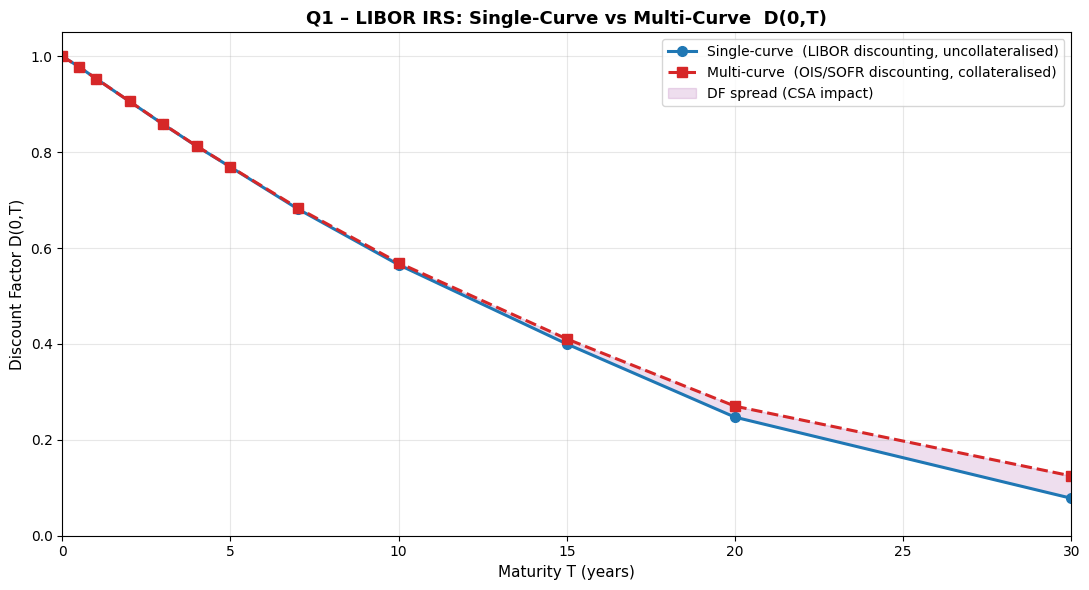

In [12]:
# Plot - LIBOR Single vs Multi-Curve

fig1, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(T_sc, DF_sc, "o-",  color="#1f77b4", lw=2.2, ms=7,
         label="Single-curve  (LIBOR discounting, uncollateralised)")
ax1.plot(T_mc, DF_mc, "s--", color="#d62728", lw=2.2, ms=7,
         label="Multi-curve  (OIS/SOFR discounting, collateralised)")
mc_at_sc = np.interp(T_sc, T_mc, DF_mc)
ax1.fill_between(T_sc, DF_sc, mc_at_sc,
                 alpha=0.13, color="purple", label="DF spread (CSA impact)")
ax1.set_title("Q1 – LIBOR IRS: Single-Curve vs Multi-Curve  D(0,T)",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Maturity T (years)", fontsize=11)
ax1.set_ylabel("Discount Factor D(0,T)", fontsize=11)
ax1.set_xlim(0, 30); ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=10); ax1.grid(alpha=0.3)
fig1.tight_layout()
plt.show()


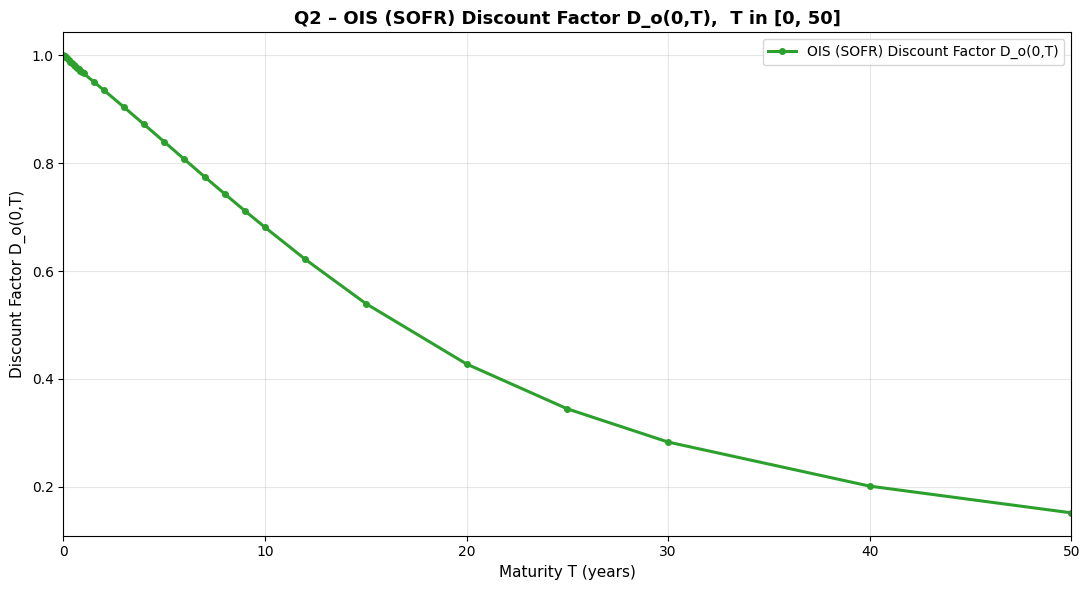

In [13]:
# Plot - OIS Discount Curve

fig2, ax2 = plt.subplots(figsize=(11, 6))
ax2.plot(T_ois, DF_ois, "o-", color="#2ca02c", lw=2.2, ms=4,
         label="OIS (SOFR) Discount Factor D_o(0,T)")
ax2.set_title("Q2 – OIS (SOFR) Discount Factor D_o(0,T),  T in [0, 50]",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Maturity T (years)", fontsize=11)
ax2.set_ylabel("Discount Factor D_o(0,T)", fontsize=11)
ax2.set_xlim(0, 50); ax2.legend(fontsize=10); ax2.grid(alpha=0.3)
fig2.tight_layout()
plt.show()


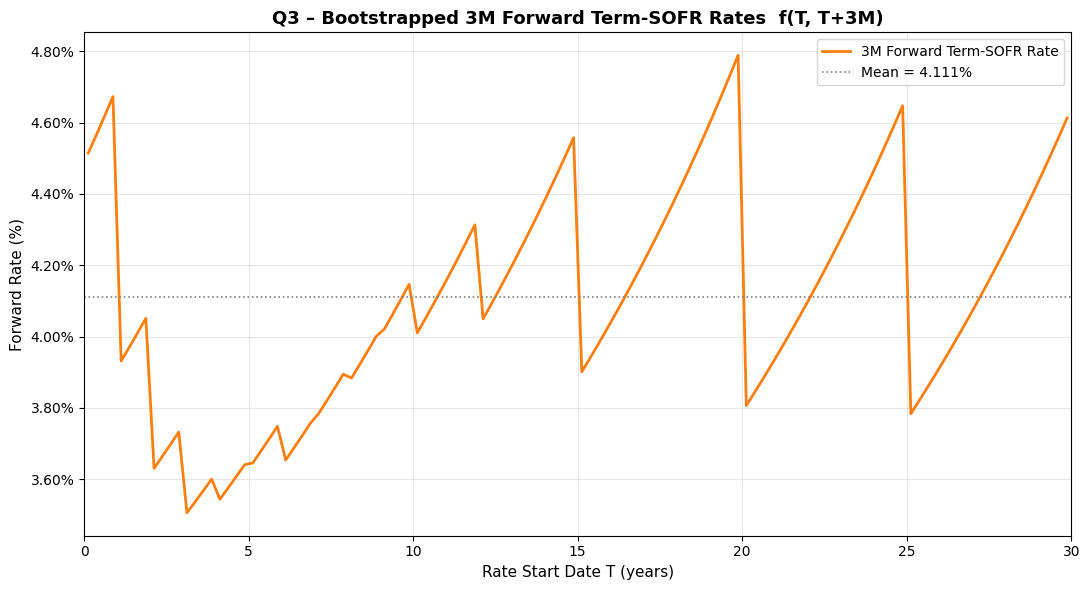

In [14]:
# Plot - 3M Forward Rates

fig3, ax3 = plt.subplots(figsize=(11, 6))
ax3.plot(fwd_t + 0.125, fwd_r * 100,
         color="#ff7f0e", lw=2, label="3M Forward Term-SOFR Rate")
ax3.axhline(y=fwd_r.mean() * 100, color="grey", ls=":", lw=1.2,
            label="Mean = {:.3f}%".format(fwd_r.mean() * 100))
ax3.set_title("Q3 – Bootstrapped 3M Forward Term-SOFR Rates  f(T, T+3M)",
              fontsize=13, fontweight="bold")
ax3.set_xlabel("Rate Start Date T (years)", fontsize=11)
ax3.set_ylabel("Forward Rate (%)", fontsize=11)
ax3.set_xlim(0, 30); ax3.legend(fontsize=10); ax3.grid(alpha=0.3)
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: "{:.2f}%".format(x)))
fig3.tight_layout()
plt.show()


In [15]:
# Summary Statistics

print("=" * 65)
print("Bootstrapping Summary")
print("=" * 65)

print("\nQ1 – LIBOR Discount Factor Spread (Single minus Multi, basis points)")
for T, sc, mc in zip(T_sc[1:], DF_sc[1:], DF_mc[1:]):
    if T in [1, 2, 5, 10, 15, 20, 30]:
        print("  D(0,{:2.0f}y):  SC={:.6f}  MC={:.6f}  spread={:.2f} bp".format(
            T, sc, mc, (sc - mc) * 1e4))

print("\nQ2 – OIS Zero Rates at key tenors")
for T in [1, 2, 5, 10, 20, 30, 50]:
    d  = float(interp1d(T_ois, DF_ois)(T))
    z  = -np.log(d) / T
    print("  r(0,{:2d}y) = {:.4f}%  |  D_OIS = {:.6f}".format(int(T), z * 100, d))

print("\nQ3 – Forward Term-SOFR statistics")
print("  Periods : {}".format(len(fwd_r)))
print("  Min     : {:.4f}%".format(fwd_r.min()  * 100))
print("  Max     : {:.4f}%".format(fwd_r.max()  * 100))
print("  Mean    : {:.4f}%".format(fwd_r.mean() * 100))
print("  Std Dev : {:.4f}%".format(fwd_r.std()  * 100))

print("\n" + "=" * 65)


Bootstrapping Summary

Q1 – LIBOR Discount Factor Spread (Single minus Multi, basis points)
  D(0, 1y):  SC=0.953641  MC=0.953653  spread=-0.13 bp
  D(0, 2y):  SC=0.905820  MC=0.906086  spread=-2.66 bp
  D(0, 5y):  SC=0.769067  MC=0.769517  spread=-4.50 bp
  D(0,10y):  SC=0.565229  MC=0.569351  spread=-41.23 bp
  D(0,15y):  SC=0.400034  MC=0.410541  spread=-105.07 bp
  D(0,20y):  SC=0.247320  MC=0.270276  spread=-229.56 bp
  D(0,30y):  SC=0.078138  MC=0.124676  spread=-465.38 bp

Q2 – OIS Zero Rates at key tenors
  r(0, 1y) = 3.4360%  |  D_OIS = 0.966224
  r(0, 2y) = 3.3428%  |  D_OIS = 0.935329
  r(0, 5y) = 3.5001%  |  D_OIS = 0.839451
  r(0,10y) = 3.8434%  |  D_OIS = 0.680901
  r(0,20y) = 4.2480%  |  D_OIS = 0.427583
  r(0,30y) = 4.2088%  |  D_OIS = 0.282910
  r(0,50y) = 3.7715%  |  D_OIS = 0.151716

Q3 – Forward Term-SOFR statistics
  Periods : 120
  Min     : 3.5059%
  Max     : 4.7886%
  Mean    : 4.1107%
  Std Dev : 0.3131%

